In [9]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if not torch.cuda.is_available():
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device: %s" % device)

Using device: cpu


In [10]:
class MNISTHDF5Dataset(Dataset):
    def __init__(self, file_path):
        with h5py.File(file_path, "r") as f:
            self.images = torch.FloatTensor(np.array(f["xdata"]))
            self.labels = np.array(f["ydata"])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].view(-1)
        label = self.labels[idx]
        if hasattr(label, '__len__') and len(label) > 1:
            label = int(np.argmax(label))
        else:
            label = int(label)
        return image, label

train_loader = DataLoader(MNISTHDF5Dataset("mnist_traindata.hdf5"), batch_size=100, shuffle=True)
test_loader = DataLoader(MNISTHDF5Dataset("mnist_testdata.hdf5"), batch_size=100, shuffle=False)

In [11]:
model = nn.Sequential(nn.Linear(784, 10)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay = 0.001)

num_epochs = 50
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    num_correct = 0
    num_samples = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        xyz, predicted = torch.max(outputs.data, 1)

        num_samples += labels.size(0)
        num_correct += (predicted == labels).sum().item()

    train_losses.append(epoch_loss / len(train_loader))
    train_accs.append(100 * num_correct / num_samples)

    model.eval()
    epoch_loss = 0.0
    num_correct = 0
    num_samples = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            epoch_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            num_samples += labels.size(0)
            num_correct += (predicted == labels).sum().item()
    test_losses.append(epoch_loss / len(test_loader))
    test_accs.append(100 * num_correct / num_samples)

print("Final Train Acc: %.2f%%  Test Acc: %.2f%%" % (train_accs[-1], test_accs[-1]))

Final Train Acc: 92.11%  Test Acc: 92.15%


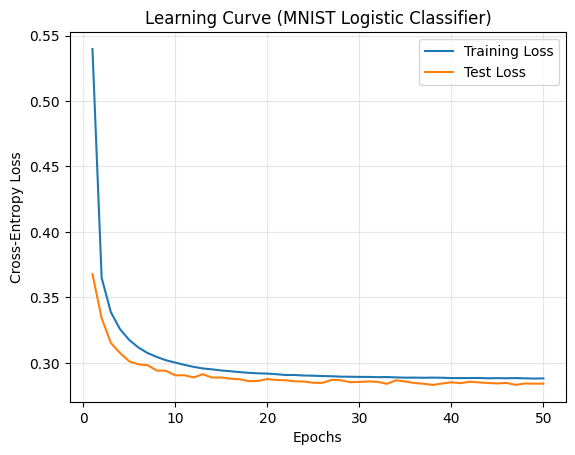

In [12]:
epochs = range(1, num_epochs + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Training Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Cross-Entropy Loss")
plt.title("Learning Curve (MNIST Logistic Classifier)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

both the curves converg well. there is a very small gap between the train and test losses. so, less overfitting. The epochs needed for the learing curve to converge is around 20-30. it platues after.

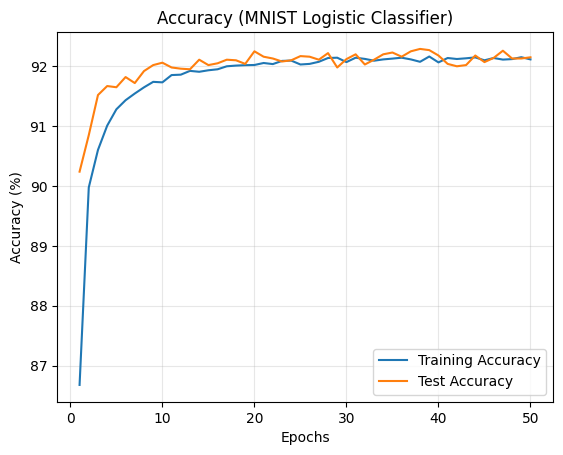

In [13]:
plt.figure()
plt.plot(epochs, train_accs, label="Training Accuracy")
plt.plot(epochs, test_accs, label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy (MNIST Logistic Classifier)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

the accuracy graphs reach 92% after 20 or so epochs after which it plateus out. The test accruacy is slighlty more erratic than train accuracy but it averages out well to a similar amount to train

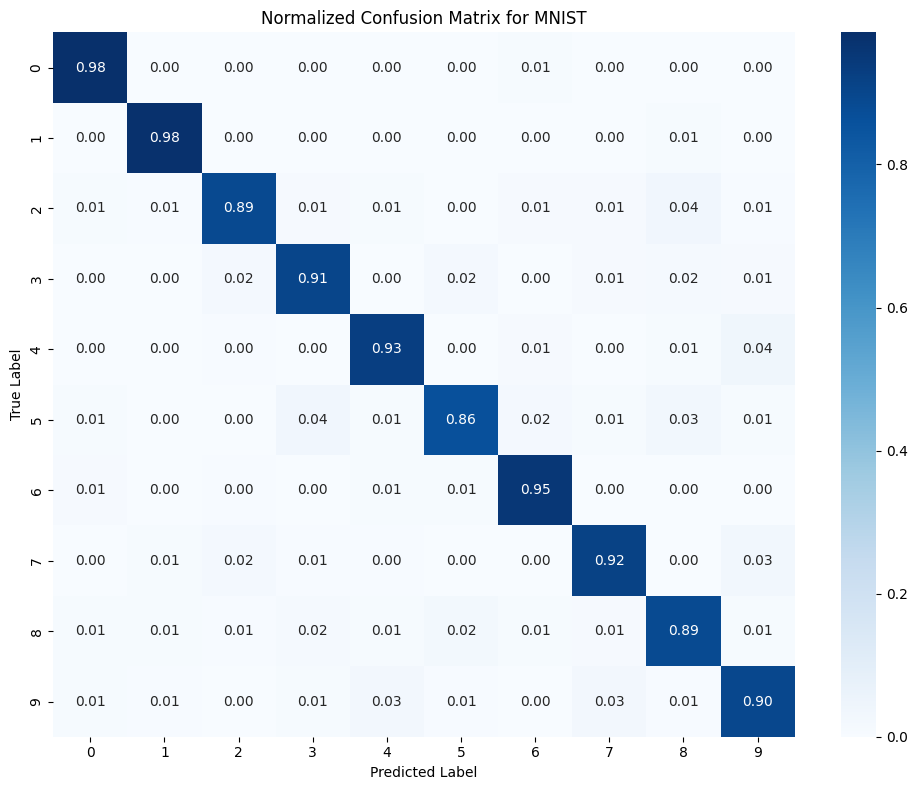

In [15]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        xyz, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix for MNIST")
plt.tight_layout()
plt.show()